# 🏥 PaliGemma Medical VQA — Demo Inference

**Notebook demo độc lập** — Load checkpoint đã fine-tune và chạy inference với ảnh y tế.

```
Cấu trúc checkpoint (từ lúc train):
  checkpoints/
    paligemma_vqarad/
      checkpoint_best/
        adapter_model/    ← LoRA weights
        processor/        ← tokenizer + image processor
        training_state.json
```

**Luồng sử dụng:**
1. Cài thư viện (Cell 1)
2. Config đường dẫn checkpoint + HF token (Cell 2)
3. Load model (Cell 3)
4. Predict với ảnh của bạn (Cell 4 trở đi)

## 📦 Cell 1: Cài đặt thư viện

In [1]:
!pip install -q transformers accelerate pillow peft bitsandbytes
!pip install -q requests
print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.3 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

## ⚙️ Cell 2: Config — chỉnh tại đây

In [2]:
# ============================================================
#  Copy checkpoint từ Kaggle Models về working dir
#  Chạy cell này trước Phần 3 khi resume
# ============================================================
import shutil, os

src = '/kaggle/input/models/nuongg/paligemma-slake/transformers/default/1/results/checkpoints'
dst = '/kaggle/working/checkpoints'

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print('✅ Copied checkpoints từ Models')
else:
    print('✅ Checkpoints đã có sẵn')

✅ Copied checkpoints từ Models


In [4]:
import torch, json, re
from pathlib import Path
from collections import Counter

# ── HuggingFace token (bắt buộc để tải base model) ──────────
# Cách 1: Dùng Kaggle Secrets (nếu chạy trên Kaggle)
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("NLP")
    print('✅ HF Token loaded từ Kaggle Secrets')
except Exception:
    # Cách 2: Điền thẳng (chạy local / Colab)
    HF_TOKEN = 'hf_...'   # ← thay token của bạn tại đây
    print('⚠️  Dùng HF_TOKEN hardcoded — nhớ xoá trước khi share notebook')

# ── Đường dẫn checkpoint ────────────────────────────────────
# Thay bằng đường dẫn thực tế đến checkpoint đã train
CHECKPOINT_DIR  = '/kaggle/working/checkpoints'   # thư mục gốc
EXPERIMENT_NAME = 'paligemma_slake'              # tên experiment

# Chọn checkpoint nào để load:
#   'best'           → checkpoint có val_f1 cao nhất
#   'last'           → checkpoint cuối cùng
#   3                → epoch cụ thể (ví dụ epoch 3)
#   '/full/path/...' → đường dẫn tuyệt đối đến folder checkpoint
LOAD_FROM = 'best'

# ── Model config (khớp với lúc train) ───────────────────────
BASE_MODEL   = 'google/paligemma-3b-pt-224'  # phải đúng model đã train
IMAGE_SIZE   = 224    # phải khớp với model (224 hoặc 448)
MAX_NEW_TOKENS = 32   # độ dài tối đa của câu trả lời

# ── Prompt style (khớp với lúc train) ───────────────────────
# dataset-v2 dùng system instruction:
PROMPT_STYLE = 'v2'  # 'v2' = có system instruction | 'v1' = chỉ question

# ── Device ──────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    USE_4BIT = vram < 20
    print(f'GPU  : {torch.cuda.get_device_name(0)} ({vram:.1f} GB)')
else:
    USE_4BIT = False
    print('⚠️  Không có GPU — inference sẽ rất chậm trên CPU')

print(f'Device : {DEVICE} | 4-bit : {USE_4BIT}')
print(f'Checkpoint dir : {CHECKPOINT_DIR}/{EXPERIMENT_NAME}')
print(f'Load from      : {LOAD_FROM}')

✅ HF Token loaded từ Kaggle Secrets
GPU  : Tesla T4 (15.6 GB)
Device : cuda | 4-bit : True
Checkpoint dir : /kaggle/working/checkpoints/paligemma_slake
Load from      : best


## 🗂️ Cell 3: Checkpoint Manager (giống lúc train)

In [5]:
class CheckpointManager:
    """Quản lý checkpoint — giống hệt class trong notebook train."""
    def __init__(self, base_dir, exp_name):
        self.exp_dir    = Path(base_dir) / exp_name
        self.state_file = self.exp_dir / 'training_state.json'

    def load(self, which='best'):
        state = self._load_state()
        if not state:
            raise FileNotFoundError(
                f'Không tìm thấy training_state.json trong {self.exp_dir}\n'
                f'Hãy chắc chắn CHECKPOINT_DIR và EXPERIMENT_NAME đúng.'
            )
        if which == 'best':
            best_dir = self.exp_dir / 'checkpoint_best'
            name = 'checkpoint_best' if best_dir.exists() else state.get('best_checkpoint', 'checkpoint_best')
        elif which == 'last':
            name = state.get('last_checkpoint')
        elif isinstance(which, int):
            name = f'checkpoint_epoch{which}'
        elif Path(which).is_absolute():
            # Đường dẫn tuyệt đối
            path = Path(which)
            if not path.exists():
                raise FileNotFoundError(f'Không tìm thấy: {path}')
            return path, state
        else:
            name = which

        path = self.exp_dir / name
        if not path.exists():
            raise FileNotFoundError(
                f'Không tìm thấy checkpoint: {path}\n'
                f'Các checkpoint hiện có: {list(self.exp_dir.glob("checkpoint_*"))}'
            )
        print(f'📂 Sẽ load: {path}')
        return path, state

    def list(self):
        state = self._load_state()
        if not state:
            print(f'❌ Không tìm thấy checkpoint nào trong: {self.exp_dir}')
            return
        print(f'\n📋 Experiment : {self.exp_dir.name}')
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        history = {h['epoch']: h for h in state.get('history', [])}
        for c in ckpts:
            ep = int(c.name.replace('checkpoint_epoch', ''))
            h  = history.get(ep, {})
            tag = ' ← LAST' if c.name == state.get('last_checkpoint') else ''
            ls  = f" loss={h['train_loss']:.4f}" if 'train_loss' in h else ''
            fs  = f" f1={h['val_f1']:.2f}%"      if 'val_f1'    in h else ''
            print(f'   {c.name}{ls}{fs}{tag}')
        best = self.exp_dir / 'checkpoint_best'
        if best.exists():
            print(f'   checkpoint_best → {state.get("best_checkpoint","?")} '
                  f'(F1={state.get("best_f1","?")}%)')
        print(f'\n   Base model : {state.get("base_model", "?")}')
        print(f'   Dataset    : {state.get("dataset", "?")}')

    def _load_state(self):
        return json.load(open(self.state_file)) if self.state_file.exists() else {}


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR, EXPERIMENT_NAME)
print('📋 Danh sách checkpoint:')
ckpt_mgr.list()

📋 Danh sách checkpoint:

📋 Experiment : paligemma_slake
   checkpoint_epoch1 loss=1.0672 f1=71.58%
   checkpoint_epoch2 loss=0.3463 f1=81.53%
   checkpoint_epoch3 loss=0.2192 f1=83.13% ← LAST
   checkpoint_best → checkpoint_epoch3 (F1=83.13%)

   Base model : google/paligemma-3b-pt-224
   Dataset    : mdwiratathya/SLAKE-vqa-english


## 🧠 Cell 4: Load Model từ Checkpoint

In [6]:
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel, prepare_model_for_kbit_training
from huggingface_hub import login

login(token=HF_TOKEN)

# ── Load checkpoint info ─────────────────────────────────────
ckpt_path, ckpt_state = ckpt_mgr.load(LOAD_FROM)

adapter_path   = ckpt_path / 'adapter_model'
processor_path = ckpt_path / 'processor'
base_model_id  = ckpt_state.get('base_model', BASE_MODEL)
use_lora       = ckpt_state.get('use_lora', True)

print(f'\n📦 Base model   : {base_model_id}')
print(f'   LoRA adapter : {adapter_path}')
print(f'   Processor    : {processor_path}')
print(f'   use_lora     : {use_lora}')

# ── 4-bit quantization config ────────────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
) if USE_4BIT else None

# ── Load processor từ checkpoint ────────────────────────────
print('\n⏳ Loading processor...')
processor = AutoProcessor.from_pretrained(processor_path)
processor.tokenizer.padding_side = 'right'
print('✅ Processor loaded')

# ── Load base model ──────────────────────────────────────────
print('\n⏳ Loading base model (có thể mất 1-2 phút)...')
base = PaliGemmaForConditionalGeneration.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    token=HF_TOKEN
)
print('✅ Base model loaded')

# ── Load LoRA weights ────────────────────────────────────────
if use_lora and adapter_path.exists():
    if USE_4BIT:
        base = prepare_model_for_kbit_training(base)
    print('\n⏳ Loading LoRA adapter...')
    model = PeftModel.from_pretrained(
        base,
        adapter_path,
        is_trainable=False   # inference only
    )
    print('✅ LoRA adapter loaded')
else:
    # Full model (không LoRA)
    full_path = ckpt_path / 'full_model'
    if full_path.exists():
        model = PaliGemmaForConditionalGeneration.from_pretrained(
            full_path, device_map='auto', torch_dtype=torch.bfloat16
        )
    else:
        print('⚠️  Không tìm thấy adapter_model/ hay full_model/ → dùng base model')
        model = base

model.eval()
print(f'\n✅ Model sẵn sàng!')
print(f'   Checkpoint : {ckpt_path.name}')
print(f'   Best F1    : {ckpt_state.get("best_f1", "N/A")}')
print(f'   Dataset    : {ckpt_state.get("dataset", "N/A")}')

📂 Sẽ load: /kaggle/working/checkpoints/paligemma_slake/checkpoint_best

📦 Base model   : google/paligemma-3b-pt-224
   LoRA adapter : /kaggle/working/checkpoints/paligemma_slake/checkpoint_best/adapter_model
   Processor    : /kaggle/working/checkpoints/paligemma_slake/checkpoint_best/processor
   use_lora     : True

⏳ Loading processor...
✅ Processor loaded

⏳ Loading base model (có thể mất 1-2 phút)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

✅ Base model loaded

⏳ Loading LoRA adapter...
✅ LoRA adapter loaded

✅ Model sẵn sàng!
   Checkpoint : checkpoint_best
   Best F1    : 83.13
   Dataset    : mdwiratathya/SLAKE-vqa-english


## 🖼️ Cell 5: Hàm xử lý ảnh + Prompt

In [8]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt


def load_image(image_input):
    """
    Load ảnh từ nhiều nguồn khác nhau:
      - str bắt đầu bằng 'http' → download từ URL
      - str khác               → đường dẫn file trên disk
      - PIL.Image               → dùng trực tiếp
      - bytes                   → decode từ bytes
    """
    if isinstance(image_input, Image.Image):
        return image_input
    if isinstance(image_input, bytes):
        return Image.open(BytesIO(image_input))
    if isinstance(image_input, str):
        if image_input.startswith('http://') or image_input.startswith('https://'):
            response = requests.get(image_input, timeout=10)
            response.raise_for_status()
            return Image.open(BytesIO(response.content))
        else:
            return Image.open(image_input)
    raise ValueError(f'Không hỗ trợ kiểu ảnh: {type(image_input)}')


def preprocess_image(image_input, image_size=IMAGE_SIZE):
    """
    Tiền xử lý ảnh cho PaliGemma:
      1. Load từ bất kỳ nguồn nào
      2. Convert sang RGB (loại bỏ alpha channel nếu có, xử lý grayscale)
      3. Resize về đúng kích thước model (224x224 hoặc 448x448)
    """
    img = load_image(image_input)

    # Nếu ảnh grayscale (L mode) hoặc có alpha (RGBA) → convert sang RGB
    if img.mode != 'RGB':
        img = img.convert('RGB')

    original_size = img.size  # (W, H)

    # Resize về đúng kích thước model cần
    img = img.resize((image_size, image_size), Image.LANCZOS)

    return img, original_size


def build_prompt(question, style=PROMPT_STYLE):
    """
    Xây dựng prompt đúng theo phong cách đã dùng lúc train.

    style='v2' (dataset-v2): có system instruction — dùng khi checkpoint từ
                              paligemma-2-dataset-v2.ipynb
    style='v1' (hope):       chỉ question đơn giản — dùng khi checkpoint từ
                              paligemma-hope.ipynb
    """
    if style == 'v2':
        return f"<image> You are a radiologist. Answer the question concisely based on the image. {question}"
    else:  # v1
        return f"<image> {question}"


def predict(
    image_input,
    question,
    max_new_tokens=MAX_NEW_TOKENS,
    show_image=True,
    verbose=True
):
    """
    Inference đầy đủ:
      1. Load & preprocess ảnh
      2. Build prompt
      3. Tokenize qua processor
      4. Generate
      5. Decode & trả về câu trả lời

    Args:
        image_input   : URL, file path, PIL.Image, hoặc bytes
        question      : câu hỏi (str)
        max_new_tokens: giới hạn độ dài output
        show_image    : hiện ảnh + kết quả bằng matplotlib
        verbose       : in thông tin chi tiết

    Returns:
        str: câu trả lời của model
    """
    # ── 1. Tiền xử lý ảnh ─────────────────────────────────────
    img, original_size = preprocess_image(image_input)
    if verbose:
        print(f'🖼️  Ảnh gốc: {original_size[0]}x{original_size[1]} → resize: {img.size[0]}x{img.size[1]}')

    # ── 2. Build prompt ────────────────────────────────────────
    prompt = build_prompt(question)
    if verbose:
        print(f'📝 Prompt : {prompt[:100]}...' if len(prompt) > 100 else f'📝 Prompt : {prompt}')

    # ── 3. Tokenize ────────────────────────────────────────────
    inputs = processor(
        images=img,
        text=prompt,
        return_tensors='pt'
    ).to(DEVICE)

    # ── 4. Generate ────────────────────────────────────────────
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False          # greedy decode → ổn định, deterministic
        )

    # ── 5. Decode — chỉ lấy phần mới sinh ra (bỏ phần prompt) ──
    prompt_len = inputs['input_ids'].shape[1]
    answer = processor.decode(
        output_ids[0][prompt_len:],
        skip_special_tokens=True
    ).strip()

    # ── 6. Hiển thị ────────────────────────────────────────────
    if show_image:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(
            f'Q: {question}\nA: {answer}',
            fontsize=11, wrap=True, loc='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
        )
        plt.tight_layout()
        plt.show()

    return answer


print('✅ Hàm predict() đã sẵn sàng!')
print('\n📌 Cách dùng:')
print('   answer = predict("path/to/image.jpg", "Is there pleural effusion?")')
print('   answer = predict("https://...",        "What organ is shown?")')

✅ Hàm predict() đã sẵn sàng!

📌 Cách dùng:
   answer = predict("path/to/image.jpg", "Is there pleural effusion?")
   answer = predict("https://...",        "What organ is shown?")


## 🔍 Cell 6: Demo — Predict với 1 ảnh

🖼️  Ảnh gốc: 555x693 → resize: 224x224
📝 Prompt : <image> You are a radiologist. Answer the question concisely based on the image. how was this image ...


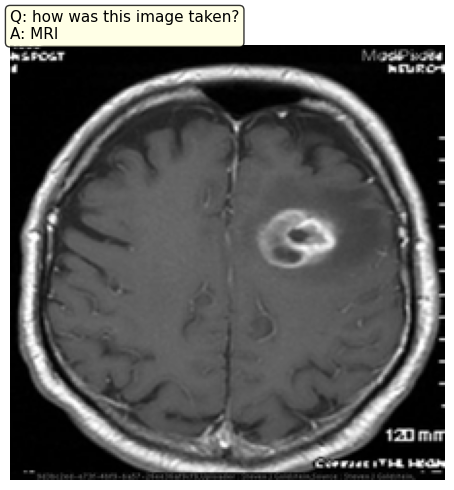


🩺 Câu trả lời: MRI


In [11]:
# ── Thay bằng ảnh thực tế của bạn ───────────────────────────
# Ví dụ 1: đường dẫn local
#IMAGE_PATH = '/kaggle/input/datasets/phcminhnmv/nao-mri/images (1).jfif'   # ← sửa tại đây

# Ví dụ 2: URL (bỏ comment nếu muốn dùng)
IMAGE_PATH = 'https://datasets-server.huggingface.co/assets/flaviagiammarino/vqa-rad/--/default/train/4/image/image.jpg?Expires=1780133442&Signature=vD4CVmLmxz1h9oP0quC-FhUo6Xd4qFm3uRFfaQKeTOTN633oFx1JBSTpddc21pCwWHxu6Zb~cYQNavVUAWCT0BCKCGezZ75hM1KB3s2igNOBS1t~oCO63Fz6YyhWy7ST99d2uxKD5I2pcm~rjpj6xKNy4dEaXoS1uYGvRg2DxZrjvQmq~WzVLLdQ5IwZFIXPRhrJnA7aXL1B5BDdYOV9gnwM92prkG4ZJKwDFKT--Z0Bl13GQdlQQ8oiUW1UjHfUF~QngrSKF~cbrhLYGgFW8Y0j7iKDMNe9yTia~l~ZxBdf4M4PwlIRlwU7ccgEO~V-bCtwsq~97jxl-1WJA7iHGg__&Key-Pair-Id=K204OQ5RWQVDLD'

QUESTION = 'how was this image taken?'           # ← câu hỏi của bạn

answer = predict(IMAGE_PATH, QUESTION)
print(f'\n🩺 Câu trả lời: {answer}')

🖼️  Ảnh gốc: 1024x1291 → resize: 224x224
📝 Prompt : <image> You are a radiologist. Answer the question concisely based on the image. which organ system ...


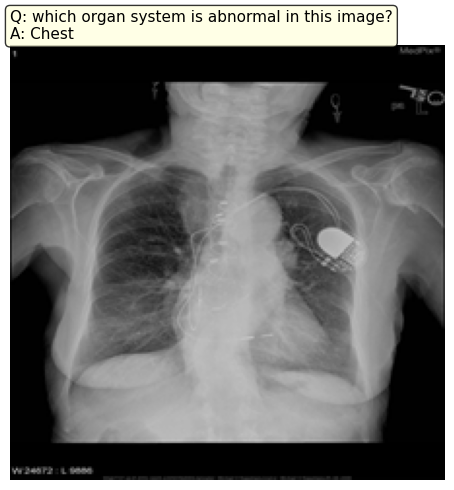


🩺 Câu trả lời: Chest


In [17]:
# ── Thay bằng ảnh thực tế của bạn ───────────────────────────
# Ví dụ 1: đường dẫn local
# IMAGE_PATH = '/kaggle/input/datasets/your_dataset/image.jpg'   # ← sửa tại đây

# Ví dụ 2: URL
IMAGE_PATH = 'https://datasets-server.huggingface.co/assets/flaviagiammarino/vqa-rad/--/default/train/2/image/image.jpg?Expires=1779190145&Signature=Vt2QXwPIJfsU4jj4leqao-D~G89A31KukqZ-rsxsqgbv3a4YsWz-bHCXvYjvnrVGtHYE-7B95zvWDQPdgu6Q8QBlTMrcvC4Q6usM6Vpc6fDM0zLm5JcD8AXFHoeJP4sODwgjiVFQyF8sFtaa1xJiqnyf6Kjb99YhrfLMc81jhoaY~yO0nMGNAukV3m9a~hUL2m-EHRq4ULUxj~0Og-aYklxLgqOsCN~mbKp7MBKOmFrCxV-waBsDoJqzKcinvfwtRcmjMRgpz54juHP46fK84emWXbCxltoWW9NmyxxI1Lhy9-htS98~ZTmjsPdbZnMCnOeSep8LTpUD7gbtCOj16g__&Key-Pair-Id=K204OQ5RWQVDLD'

QUESTION = 'which organ system is abnormal in this image?'   # ← câu hỏi của bạn

answer = predict(IMAGE_PATH, QUESTION)
print(f'\n🩺 Câu trả lời: {answer}')

🔄 Đang predict...
✅ Prediction: Yes
📥 Loading sentence transformer (lần đầu ~30s)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Câu hỏi     : are the kidneys visualized?
  Ground Truth: yes  [CLOSED]
  Prediction  : Yes
  Kết quả     : ✅ ĐÚNG
-------------------------------------------------------
  Exact Match        : 1      (1=khớp hoàn toàn)
  Token F1           : 1.0000  (0–1)
  BLEU-1             : 1.0000  (0–1)
  BLEU-4             : 0.1778  (0–1)
  ROUGE-L            : 1.0000  (0–1)
  Cosine Similarity  : 1.0000  (-1 đến 1, semantic)


/tmp/ipykernel_79/3711273656.py:144: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79/3711273656.py:145: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


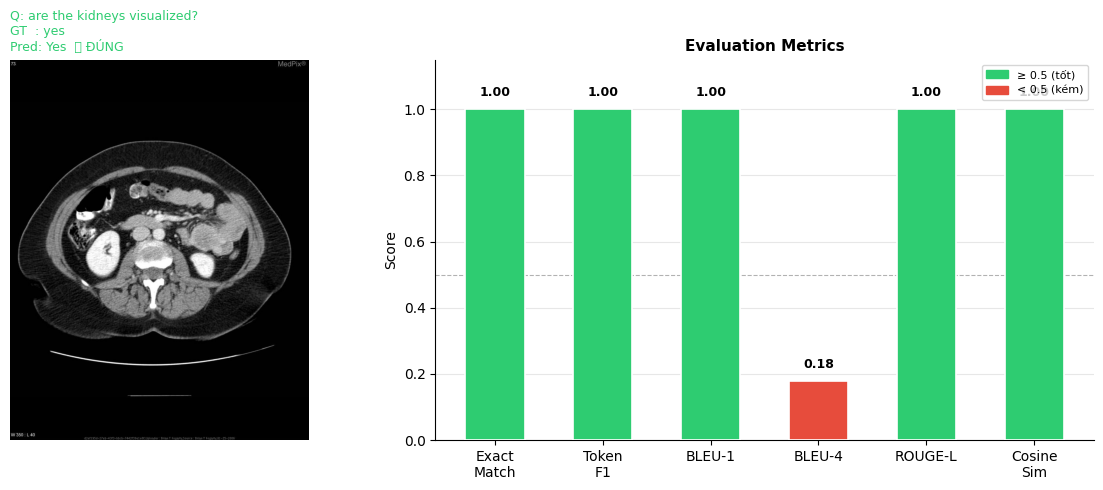

✅ Saved: single_eval.png


In [21]:
# ================================================================
#  ĐÁNH GIÁ 1 CÂU TRẢ LỜI VỚI GROUND TRUTH — nhập tay từ ngoài
# ================================================================
# Thay 3 dòng bên dưới, chạy cell là có kết quả đầy đủ.

IMAGE_PATH   = 'https://datasets-server.huggingface.co/cached-assets/flaviagiammarino/vqa-rad/--/bcf91e7654fb9d51c8ab6a5b82cacf3fafd2fae9/--/default/train/51/image/image.jpg?Expires=1779193642&Signature=mThCpELn62~MQ1D1QuWNi3U2P3HdEDxov~GcALv~EgZBJxg1Ef0MLeO-USo3jULksXNDdPG25sb6HuBDiRikyXVJ2qZ0uvZYdxYQpHDRkBVFRhVjh1-xEy-1mbr2cE9wMq2M42CrKY9hibV~vq9PNjh1pIotuImRJdoPvmknbu4iRHzG3XV8lDRbr10A~NCwOfZQSULlmNWZynDceVwgk9P~iAOcxfPX5JF~9qbz-SxINQcvLQNBeEflClPfPSqDsmpivO-0PSH8DFvBzNAjQPSOGoWQunAT~ueT1jD9ocNGSMUP72o5YgqdJMGOWTEtM4ZJhlpe4Depx9zWYuBBSw__&Key-Pair-Id=K204OQ5RWQVDLD'
QUESTION     = 'are the kidneys visualized?'   # ← câu hỏi
GROUND_TRUTH = 'yes'                                      # ← đáp án đúng

# ── Cài thêm nếu chưa có ────────────────────────────────────────
import subprocess, sys
for pkg in ['rouge-score', 'sentence-transformers', 'nltk']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import re, math, io
from collections import Counter
import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_scorer_lib
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos

# ── Load ảnh (URL hoặc local path) ──────────────────────────────
def load_image(src):
    if str(src).startswith('http'):
        resp = requests.get(src, timeout=15)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert('RGB')
    return Image.open(src).convert('RGB')

img = load_image(IMAGE_PATH)

# ── Predict ──────────────────────────────────────────────────────
print('🔄 Đang predict...')
prediction = predict(IMAGE_PATH, QUESTION, show_image=False, verbose=False)
print(f'✅ Prediction: {prediction}')

# ── Helper: normalize ────────────────────────────────────────────
def _norm(t):
    t = t.lower().strip()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# ── Metrics ──────────────────────────────────────────────────────
pred_n  = _norm(prediction)
gt_n    = _norm(GROUND_TRUTH)
pred_tok = pred_n.split()
gt_tok   = gt_n.split()

# 1. Exact Match
em = int(pred_n == gt_n)

# 2. Token F1
common   = Counter(pred_tok) & Counter(gt_tok)
n_common = sum(common.values())
if n_common == 0:
    f1 = 0.0
else:
    prec = n_common / len(pred_tok)
    rec  = n_common / len(gt_tok)
    f1   = 2 * prec * rec / (prec + rec)

# 3. BLEU-1
smoothie = SmoothingFunction().method1
bleu1 = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
bleu4 = sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie)

# 4. ROUGE-L
scorer = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = scorer.score(GROUND_TRUTH, prediction)['rougeL'].fmeasure

# 5. Cosine Similarity (semantic embedding)
print('📥 Loading sentence transformer (lần đầu ~30s)...')
_sim_model = SentenceTransformer('all-MiniLM-L6-v2')
emb_p = _sim_model.encode([prediction])
emb_g = _sim_model.encode([GROUND_TRUTH])
cosine = float(sk_cos(emb_p, emb_g)[0][0])

# 6. Q-type
q_type = 'CLOSED' if gt_n in ['yes', 'no'] else 'OPEN'
verdict = '✅ ĐÚNG' if em else '❌ SAI'

# ── In kết quả ───────────────────────────────────────────────────
print()
print('=' * 55)
print(f'  Câu hỏi     : {QUESTION}')
print(f'  Ground Truth: {GROUND_TRUTH}  [{q_type}]')
print(f'  Prediction  : {prediction}')
print(f'  Kết quả     : {verdict}')
print('-' * 55)
print(f'  Exact Match        : {em}      (1=khớp hoàn toàn)')
print(f'  Token F1           : {f1:.4f}  (0–1)')
print(f'  BLEU-1             : {bleu1:.4f}  (0–1)')
print(f'  BLEU-4             : {bleu4:.4f}  (0–1)')
print(f'  ROUGE-L            : {rouge_l:.4f}  (0–1)')
print(f'  Cosine Similarity  : {cosine:.4f}  (-1 đến 1, semantic)')
print('=' * 55)

# ── Visualize ────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.4]})

# --- Ảnh ---
ax_img.imshow(img, cmap='gray')
ax_img.axis('off')
border_color = '#2ecc71' if em else '#e74c3c'
for sp in ax_img.spines.values():
    sp.set_edgecolor(border_color); sp.set_linewidth(5); sp.set_visible(True)
ax_img.set_title(
    f'Q: {QUESTION}\n'
    f'GT  : {GROUND_TRUTH}\n'
    f'Pred: {prediction}  {verdict}',
    fontsize=9, loc='left', color=border_color, pad=6
)

# --- Bar chart metrics ---
metrics  = ['Exact\nMatch', 'Token\nF1', 'BLEU-1', 'BLEU-4', 'ROUGE-L', 'Cosine\nSim']
values   = [em, f1, bleu1, bleu4, rouge_l, cosine]
colors   = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in values]

bars = ax_bar.bar(metrics, values, color=colors, edgecolor='white', linewidth=1.2,
                  zorder=3, width=0.55)
ax_bar.set_ylim(0, 1.15)
ax_bar.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=2)
ax_bar.set_ylabel('Score', fontsize=10)
ax_bar.set_title('Evaluation Metrics', fontsize=11, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3, zorder=1)
ax_bar.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

good_p = mpatches.Patch(color='#2ecc71', label='≥ 0.5 (tốt)')
bad_p  = mpatches.Patch(color='#e74c3c', label='< 0.5 (kém)')
ax_bar.legend(handles=[good_p, bad_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: single_eval.png')


🔄 Đang predict...
✅ Prediction: CT
📥 Loading sentence transformer (lần đầu ~30s)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Câu hỏi     : what image modality is this?
  Ground Truth: ct  [OPEN]
  Prediction  : CT
  Kết quả     : ✅ ĐÚNG
-------------------------------------------------------
  Exact Match        : 1      (1=khớp hoàn toàn)
  Token F1           : 1.0000  (0–1)
  BLEU-1             : 1.0000  (0–1)
  BLEU-4             : 0.1778  (0–1)
  ROUGE-L            : 1.0000  (0–1)
  Cosine Similarity  : 1.0000  (-1 đến 1, semantic)


/tmp/ipykernel_79/37432304.py:144: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_79/37432304.py:145: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


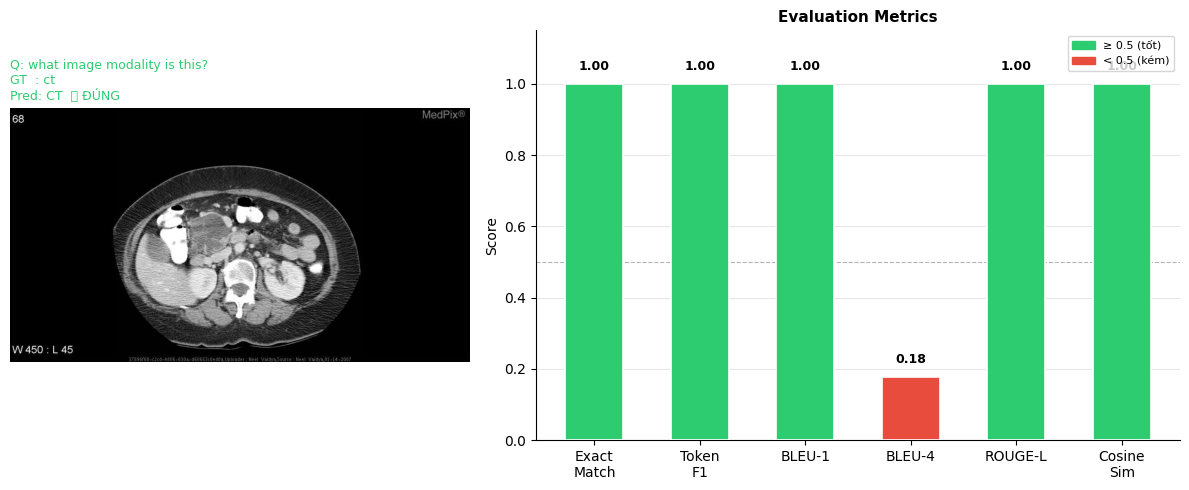

✅ Saved: single_eval.png


In [22]:
# ================================================================
#  ĐÁNH GIÁ 1 CÂU TRẢ LỜI VỚI GROUND TRUTH — nhập tay từ ngoài
# ================================================================
# Thay 3 dòng bên dưới, chạy cell là có kết quả đầy đủ.

IMAGE_PATH   = 'https://datasets-server.huggingface.co/cached-assets/flaviagiammarino/vqa-rad/--/bcf91e7654fb9d51c8ab6a5b82cacf3fafd2fae9/--/default/train/67/image/image.jpg?Expires=1779193642&Signature=WsgIFPoABA3TZkcw7OjrE~WWhS3HBkC8Bt1knn8D0~fjVJQKaXDQ3O90-cCwZDLj-zYybwmwkGPGqfDRxPk5Bmja0WN0tqC-i5UZeAq9XQyk5LfuCUmPuTLZNrt~fR4kBefKmR9Li6jin6DRLGtt1ZVFEV8XgPcRX8mun4USlOknu-Q38oJ5Psn4MONOdYFua4pDIhK8L07umqeXmcqoGHF82cqYlQ7Gyw1W6M25wHLYyri0v3WfLuQWyH9H~fRBg7MIjPejIbDeZCS-VAd49I5fYiED0wHNL9UmAgtBt44DSYRGxXjtBrAfAr0Kf1At7vaFDUzPBhaeg7JSeQjgMw__&Key-Pair-Id=K204OQ5RWQVDLD'
QUESTION     = 'what image modality is this?'   # ← câu hỏi
GROUND_TRUTH = 'ct'                                      # ← đáp án đúng

# ── Cài thêm nếu chưa có ────────────────────────────────────────
import subprocess, sys
for pkg in ['rouge-score', 'sentence-transformers', 'nltk']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

import re, math, io
from collections import Counter
import requests
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer as rouge_scorer_lib
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos

# ── Load ảnh (URL hoặc local path) ──────────────────────────────
def load_image(src):
    if str(src).startswith('http'):
        resp = requests.get(src, timeout=15)
        resp.raise_for_status()
        return Image.open(io.BytesIO(resp.content)).convert('RGB')
    return Image.open(src).convert('RGB')

img = load_image(IMAGE_PATH)

# ── Predict ──────────────────────────────────────────────────────
print('🔄 Đang predict...')
prediction = predict(IMAGE_PATH, QUESTION, show_image=False, verbose=False)
print(f'✅ Prediction: {prediction}')

# ── Helper: normalize ────────────────────────────────────────────
def _norm(t):
    t = t.lower().strip()
    t = re.sub(r'[^\w\s]', '', t)
    return re.sub(r'\s+', ' ', t).strip()

# ── Metrics ──────────────────────────────────────────────────────
pred_n  = _norm(prediction)
gt_n    = _norm(GROUND_TRUTH)
pred_tok = pred_n.split()
gt_tok   = gt_n.split()

# 1. Exact Match
em = int(pred_n == gt_n)

# 2. Token F1
common   = Counter(pred_tok) & Counter(gt_tok)
n_common = sum(common.values())
if n_common == 0:
    f1 = 0.0
else:
    prec = n_common / len(pred_tok)
    rec  = n_common / len(gt_tok)
    f1   = 2 * prec * rec / (prec + rec)

# 3. BLEU-1
smoothie = SmoothingFunction().method1
bleu1 = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
bleu4 = sentence_bleu([gt_tok], pred_tok, weights=(.25,.25,.25,.25), smoothing_function=smoothie)

# 4. ROUGE-L
scorer = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)
rouge_l = scorer.score(GROUND_TRUTH, prediction)['rougeL'].fmeasure

# 5. Cosine Similarity (semantic embedding)
print('📥 Loading sentence transformer (lần đầu ~30s)...')
_sim_model = SentenceTransformer('all-MiniLM-L6-v2')
emb_p = _sim_model.encode([prediction])
emb_g = _sim_model.encode([GROUND_TRUTH])
cosine = float(sk_cos(emb_p, emb_g)[0][0])

# 6. Q-type
q_type = 'CLOSED' if gt_n in ['yes', 'no'] else 'OPEN'
verdict = '✅ ĐÚNG' if em else '❌ SAI'

# ── In kết quả ───────────────────────────────────────────────────
print()
print('=' * 55)
print(f'  Câu hỏi     : {QUESTION}')
print(f'  Ground Truth: {GROUND_TRUTH}  [{q_type}]')
print(f'  Prediction  : {prediction}')
print(f'  Kết quả     : {verdict}')
print('-' * 55)
print(f'  Exact Match        : {em}      (1=khớp hoàn toàn)')
print(f'  Token F1           : {f1:.4f}  (0–1)')
print(f'  BLEU-1             : {bleu1:.4f}  (0–1)')
print(f'  BLEU-4             : {bleu4:.4f}  (0–1)')
print(f'  ROUGE-L            : {rouge_l:.4f}  (0–1)')
print(f'  Cosine Similarity  : {cosine:.4f}  (-1 đến 1, semantic)')
print('=' * 55)

# ── Visualize ────────────────────────────────────────────────────
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 5),
                                     gridspec_kw={'width_ratios': [1, 1.4]})

# --- Ảnh ---
ax_img.imshow(img, cmap='gray')
ax_img.axis('off')
border_color = '#2ecc71' if em else '#e74c3c'
for sp in ax_img.spines.values():
    sp.set_edgecolor(border_color); sp.set_linewidth(5); sp.set_visible(True)
ax_img.set_title(
    f'Q: {QUESTION}\n'
    f'GT  : {GROUND_TRUTH}\n'
    f'Pred: {prediction}  {verdict}',
    fontsize=9, loc='left', color=border_color, pad=6
)

# --- Bar chart metrics ---
metrics  = ['Exact\nMatch', 'Token\nF1', 'BLEU-1', 'BLEU-4', 'ROUGE-L', 'Cosine\nSim']
values   = [em, f1, bleu1, bleu4, rouge_l, cosine]
colors   = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in values]

bars = ax_bar.bar(metrics, values, color=colors, edgecolor='white', linewidth=1.2,
                  zorder=3, width=0.55)
ax_bar.set_ylim(0, 1.15)
ax_bar.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, zorder=2)
ax_bar.set_ylabel('Score', fontsize=10)
ax_bar.set_title('Evaluation Metrics', fontsize=11, fontweight='bold')
ax_bar.grid(axis='y', alpha=0.3, zorder=1)
ax_bar.spines[['top', 'right']].set_visible(False)

for bar, val in zip(bars, values):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

good_p = mpatches.Patch(color='#2ecc71', label='≥ 0.5 (tốt)')
bad_p  = mpatches.Patch(color='#e74c3c', label='< 0.5 (kém)')
ax_bar.legend(handles=[good_p, bad_p], fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('single_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: single_eval.png')


## 📋 Cell 7: Hỏi nhiều câu về cùng 1 ảnh

In [13]:
IMAGE_PATH = 'https://datasets-server.huggingface.co/assets/flaviagiammarino/vqa-rad/--/default/train/5/image/image.jpg?Expires=1779189844&Signature=Ze2f16ioodGXOKb1woFadMAjAgO8T17gYD77jxkMVWSf~9N0a7XQlbNOr~~hf7Smtp2MTDkC1k3AdOnuo5qigqdgxn0c8QjXWEnvW1jpaECWXetQUTFEvGC5ynpbX783XlmYuBHywwoxMGxFXZlRwcqeoOxnNwQRSJeJuSJuZckDt2Xq4ShkWrMGnENavXJJPu2uHH76A83Reba8Uy4i89hQ0GAG1ReC0FR~LbSxmAH-mBB6E7Z6Cnw3ZYFVs5bBsGP826HQXyvzFyWW3PBRhu4WH8Oy8sk3sRHb5pNBo3UQmJnqRmJ8pRizNRKkyFGEa10RQ7Ru6svIz-W274crZA__&Key-Pair-Id=K204OQ5RWQVDLD'   # ← sửa tại đây

questions = [
    # 1. Nhóm câu hỏi dạng Yes/No (Phát hiện dấu hiệu)
    'Is there evidence of intracranial hemorrhage?',          # Có dấu hiệu xuất huyết nội sọ không?
    'Does the image show any mass effect or midline shift?',  # Ảnh có cho thấy hiệu ứng khối hoặc lệch đường giữa không?
    'Are the ventricles normal in size?',                     # Kích thước các não thất có bình thường không?
    'Is there any sign of acute infarction?',                 # Có dấu hiệu nhồi máu cấp tính không?
    'Is there a skull fracture visible?',                     # Có thấy nứt vỡ hộp sọ không?

    # 2. Nhóm câu hỏi về Vị trí (Localization)
    'Which lobe of the brain is the lesion located in?',      # Tổn thương nằm ở thùy não nào?
    'Is the abnormality in the left or right hemisphere?',    # Bất thường ở bán cầu não trái hay phải?
    'Where is the tumor situated?',                           # Khối u nằm ở đâu?

    # 3. Nhóm câu hỏi về Đặc điểm hình ảnh & Phân loại (Attributes/Classification)
    'What type of hemorrhage is shown in this scan?',         # Loại xuất huyết nào được hiển thị trong ảnh chụp này? (vd: Epidural, Subdural...)
    'Is the lesion hyperdense or hypodense?',                 # Tổn thương là tăng tỷ trọng hay giảm tỷ trọng?
    'What imaging modality is used for this brain scan?',     # Phương pháp chẩn đoán hình ảnh nào được sử dụng? (CT hay MRI)
    'Is this a T1-weighted or T2-weighted MRI?',              # Đây là ảnh MRI xung T1 hay T2?
    'Is contrast material used in this scan?',                # Ảnh chụp này có sử dụng thuốc cản quang không?

    # 4. Nhóm câu hỏi Đánh giá tổng quát
    'What is the most likely diagnosis based on this image?', # Chẩn đoán có khả năng nhất dựa trên ảnh này là gì?
    'Are there multiple lesions or a single lesion?'          # Có nhiều tổn thương hay chỉ một tổn thương đơn lẻ?
]

# Preprocess ảnh 1 lần, dùng lại cho nhiều câu hỏi
img, original_size = preprocess_image(IMAGE_PATH)
print(f'🖼️  Ảnh: {original_size[0]}x{original_size[1]} → {img.size[0]}x{img.size[1]}')
print('=' * 60)

for q in questions:
    ans = predict(img, q, show_image=False, verbose=False)
    print(f'Q: {q}')
    print(f'A: {ans}')
    print('-' * 40)

🖼️  Ảnh: 1024x655 → 224x224
Q: Is there evidence of intracranial hemorrhage?
A: No
----------------------------------------
Q: Does the image show any mass effect or midline shift?
A: No
----------------------------------------
Q: Are the ventricles normal in size?
A: Yes
----------------------------------------
Q: Is there any sign of acute infarction?
A: No
----------------------------------------
Q: Is there a skull fracture visible?
A: No
----------------------------------------
Q: Which lobe of the brain is the lesion located in?
A: Right Lobe
----------------------------------------
Q: Is the abnormality in the left or right hemisphere?
A: Right
----------------------------------------
Q: Where is the tumor situated?
A: Right
----------------------------------------
Q: What type of hemorrhage is shown in this scan?
A: Spinal
----------------------------------------
Q: Is the lesion hyperdense or hypodense?
A: Hypodense
----------------------------------------
Q: What imaging moda

In [12]:
IMAGE_PATH = 'https://www.vinmec.com/static/uploads/20190712_095007_870902_Luu_y_khi_chup_CT_p_max_1800x1800_jpg_a55a137dae.jpg'   # ← sửa tại đây

lung_questions = [
    'Is there any opacity or nodule in the lungs?',       # (Hỏi về dấu hiệu bệnh lý cụ thể như bóng mờ/nốt sần ở phổi)
    'What organ is shown in the image?',                  # (Model sẽ nhận diện và trả lời là "Lung")
    'Is there any abnormality in the lungs?',             # (Hỏi về bất thường tổng quát ở phổi)
    'Which lung is affected, the left or the right?',     # (Hỏi về vị trí phổi trái hay phải bị tổn thương)
]

# Preprocess ảnh 1 lần, dùng lại cho nhiều câu hỏi
img, original_size = preprocess_image(IMAGE_PATH)
print(f'🖼️  Ảnh: {original_size[0]}x{original_size[1]} → {img.size[0]}x{img.size[1]}')
print('=' * 60)

for q in lung_questions:
    ans = predict(img, q, show_image=False, verbose=False)
    print(f'Q: {q}')
    print(f'A: {ans}')
    print('-' * 40)

🖼️  Ảnh: 600x372 → 224x224
Q: Is there any opacity or nodule in the lungs?
A: Yes
----------------------------------------
Q: What organ is shown in the image?
A: Lung
----------------------------------------
Q: Is there any abnormality in the lungs?
A: Yes
----------------------------------------
Q: Which lung is affected, the left or the right?
A: Left
----------------------------------------


## 📁 Cell 8: Batch predict từ folder ảnh

In [18]:
import os
import pandas as pd
from tqdm.auto import tqdm

IMAGE_FOLDER = '/path/to/your/images/'    # ← sửa tại đây
DEFAULT_QUESTION = 'What abnormality is present in the image?'

# Hỗ trợ jpg, jpeg, png, bmp, tiff
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

image_files = [
    f for f in Path(IMAGE_FOLDER).iterdir()
    if f.suffix.lower() in SUPPORTED_EXTS
]

print(f'📂 Tìm thấy {len(image_files)} ảnh trong {IMAGE_FOLDER}')

results = []
for img_path in tqdm(image_files, desc='Predicting'):
    try:
        ans = predict(str(img_path), DEFAULT_QUESTION, show_image=False, verbose=False)
        results.append({'filename': img_path.name, 'question': DEFAULT_QUESTION, 'answer': ans, 'error': None})
    except Exception as e:
        results.append({'filename': img_path.name, 'question': DEFAULT_QUESTION, 'answer': None, 'error': str(e)})

df = pd.DataFrame(results)
print(f'\n✅ Kết quả:')
print(df.to_string(index=False))

# Lưu ra CSV
output_csv = 'predictions.csv'
df.to_csv(output_csv, index=False)
print(f'\n💾 Đã lưu kết quả → {output_csv}')

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/your/images'

## 📊 Cell 9: Evaluate trên tập test (nếu có ground truth)

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm

# ── Metrics helpers ──────────────────────────────────────────
def normalize(s):
    return re.sub(r'[^a-z0-9 ]', '', str(s).lower().strip())

def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g:
        return 0.0
    n = sum((Counter(p) & Counter(g)).values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(g)
    return 2 * prec * rec / (prec + rec)

# ── Load dataset test ────────────────────────────────────────
DATASET_NAME = ckpt_state.get('dataset', 'flaviagiammarino/vqa-rad')
print(f'📥 Loading test set từ {DATASET_NAME}...')
raw_ds = load_dataset(DATASET_NAME)
test_data = raw_ds['test']
Q_COL, A_COL = 'question', 'answer'

# Limit để test nhanh — bỏ [:50] để chạy toàn bộ
N_EVAL = 50
test_data = test_data.select(range(min(N_EVAL, len(test_data))))
print(f'Evaluate trên {len(test_data)} samples...')

# ── Run evaluation ───────────────────────────────────────────
preds, gts, q_types = [], [], []

for item in tqdm(test_data, desc='Evaluating'):
    ans = predict(item['image'], item[Q_COL], show_image=False, verbose=False)
    preds.append(ans)
    gts.append(str(item[A_COL]))
    q_types.append('CLOSED' if str(item[A_COL]).lower() in ['yes', 'no'] else 'OPEN')

# ── Tính metrics ─────────────────────────────────────────────
f1s  = [token_f1(p, g) for p, g in zip(preds, gts)]
accs = [int(normalize(p) == normalize(g)) for p, g in zip(preds, gts)]

overall_f1  = sum(f1s)  / len(f1s)  * 100
overall_acc = sum(accs) / len(accs) * 100

closed_f1  = [f for f, t in zip(f1s, q_types) if t == 'CLOSED']
open_f1    = [f for f, t in zip(f1s, q_types) if t == 'OPEN']
closed_acc = [a for a, t in zip(accs, q_types) if t == 'CLOSED']
open_acc   = [a for a, t in zip(accs, q_types) if t == 'OPEN']

print(f'\n📊 Kết quả Evaluate ({len(preds)} samples):')
print(f'   Overall   — F1: {overall_f1:.2f}%  |  Acc: {overall_acc:.2f}%')
if closed_f1:
    print(f'   Closed Q  — F1: {sum(closed_f1)/len(closed_f1)*100:.2f}%  |  Acc: {sum(closed_acc)/len(closed_acc)*100:.2f}%  ({len(closed_f1)} samples)')
if open_f1:
    print(f'   Open Q    — F1: {sum(open_f1)/len(open_f1)*100:.2f}%  |  Acc: {sum(open_acc)/len(open_acc)*100:.2f}%  ({len(open_f1)} samples)')

# ── Hiện một số ví dụ sai ───────────────────────────────────
print('\n🔍 Ví dụ sai (F1 < 0.5):')
wrong = [(test_data[i][Q_COL], gts[i], preds[i], f1s[i])
         for i in range(len(preds)) if f1s[i] < 0.5]
for q, gt, pred, f1 in wrong[:5]:
    print(f'   Q    : {q}')
    print(f'   GT   : {gt}')
    print(f'   Pred : {pred}  (F1={f1:.3f})')
    print()

## 🌐 Cell 10: Gradio Web Demo — Giao diện trực quan

In [12]:
# ================================================================
#  GRADIO WEB DEMO — PaliGemma Medical VQA
#  Giao diện đẹp, hỗ trợ:
#    Tab 1: Predict — upload ảnh + hỏi → trả lời
#    Tab 2: Evaluate — upload ảnh + hỏi + ground truth → metrics
#    Tab 3: Multi-Q  — 1 ảnh, nhiều câu hỏi cùng lúc
# ================================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gradio>=4.0'], check=False)

import gradio as gr
import re, io
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from PIL import Image

# ── Màu sắc & tiêu đề ────────────────────────────────────────────
PRIMARY   = '#0ea5e9'   # sky-500
SUCCESS   = '#22c55e'   # green-500
DANGER    = '#ef4444'   # red-500
BG_DARK   = '#0f172a'   # slate-900
BG_CARD   = '#1e293b'   # slate-800
TEXT_MUTE = '#94a3b8'   # slate-400

# ── Helper: normalize text ────────────────────────────────────────
def _norm(t):
    t = re.sub(r'[^\w\s]', '', str(t).lower().strip())
    return re.sub(r'\s+', ' ', t).strip()

def token_f1(pred, gold):
    p, g = _norm(pred).split(), _norm(gold).split()
    if not p or not g: return 0.0
    n = sum((Counter(p) & Counter(g)).values())
    if n == 0: return 0.0
    prec, rec = n/len(p), n/len(g)
    return 2*prec*rec/(prec+rec)

# ── Tab 1: Predict ────────────────────────────────────────────────
def tab_predict(image, question, max_tokens):
    if image is None:
        return '⚠️ Vui lòng upload ảnh trước.', None
    if not question.strip():
        return '⚠️ Vui lòng nhập câu hỏi.', None
    try:
        pil_img = Image.fromarray(image).convert('RGB')
        answer  = predict(pil_img, question, max_new_tokens=int(max_tokens),
                          show_image=False, verbose=False)

        # Vẽ ảnh kèm Q&A
        fig, ax = plt.subplots(figsize=(6, 6), facecolor=BG_DARK)
        ax.set_facecolor(BG_DARK)
        ax.imshow(pil_img)
        ax.axis('off')
        wrap = 52
        q_wrap = '\n'.join([question[i:i+wrap] for i in range(0, len(question), wrap)])
        a_wrap = '\n'.join([answer[i:i+wrap]   for i in range(0, len(answer), wrap)])
        ax.text(0.01, 0.01,
                f'❓ {q_wrap}\n🩺 {a_wrap}',
                transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#0f172acc',
                          edgecolor=PRIMARY, linewidth=1.5),
                color='white')
        plt.tight_layout(pad=0.3)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
                    facecolor=BG_DARK)
        plt.close(fig)
        buf.seek(0)
        result_img = Image.open(buf)
        return f'### 🩺 Câu trả lời:\n> **{answer}**', result_img
    except Exception as e:
        return f'❌ Lỗi: {e}', None

# ── Tab 2: Evaluate ───────────────────────────────────────────────
def tab_evaluate(image, question, ground_truth):
    if image is None:
        return '⚠️ Vui lòng upload ảnh trước.', None
    if not question.strip() or not ground_truth.strip():
        return '⚠️ Cần điền cả câu hỏi và ground truth.', None
    try:
        from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
        from rouge_score import rouge_scorer as rouge_scorer_lib

        pil_img = Image.fromarray(image).convert('RGB')
        prediction = predict(pil_img, question, show_image=False, verbose=False)

        pred_n  = _norm(prediction)
        gt_n    = _norm(ground_truth)
        pred_tok, gt_tok = pred_n.split(), gt_n.split()

        em   = int(pred_n == gt_n)
        f1   = token_f1(prediction, ground_truth)
        sm   = SmoothingFunction().method1
        b1   = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=sm)
        b4   = sentence_bleu([gt_tok], pred_tok, weights=(.25,)*4,  smoothing_function=sm)
        rl   = rouge_scorer_lib.RougeScorer(['rougeL'], use_stemmer=True)\
                   .score(ground_truth, prediction)['rougeL'].fmeasure
        verdict = '✅ ĐÚNG' if em else '❌ SAI'
        q_type  = 'CLOSED' if gt_n in ['yes','no'] else 'OPEN'

        summary = (
            f'### Kết quả: {verdict}  `[{q_type}]`\n'
            f'- **Ground Truth:** `{ground_truth}`\n'
            f'- **Prediction:**   `{prediction}`\n\n'
            f'| Metric | Score |\n|--------|-------|\n'
            f'| Exact Match | `{em}` |\n'
            f'| Token F1 | `{f1:.4f}` |\n'
            f'| BLEU-1 | `{b1:.4f}` |\n'
            f'| BLEU-4 | `{b4:.4f}` |\n'
            f'| ROUGE-L | `{rl:.4f}` |'
        )

        # Vẽ biểu đồ metrics
        fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4.5),
                                              facecolor=BG_DARK,
                                              gridspec_kw={'width_ratios':[1,1.4]})
        for ax in (ax_img, ax_bar): ax.set_facecolor(BG_DARK)

        ax_img.imshow(pil_img); ax_img.axis('off')
        bc = SUCCESS if em else DANGER
        for sp in ax_img.spines.values():
            sp.set_edgecolor(bc); sp.set_linewidth(4); sp.set_visible(True)
        ax_img.set_title(f'GT: {ground_truth}\nPred: {prediction}  {verdict}',
                         fontsize=9, color=bc, loc='left', pad=5)

        labels = ['Exact\nMatch','Token F1','BLEU-1','BLEU-4','ROUGE-L']
        vals   = [em, f1, b1, b4, rl]
        colors = [SUCCESS if v>=0.5 else DANGER for v in vals]
        bars = ax_bar.bar(labels, vals, color=colors, edgecolor='#334155',
                          linewidth=1, width=0.55, zorder=3)
        ax_bar.set_ylim(0, 1.2)
        ax_bar.axhline(0.5, color=TEXT_MUTE, ls='--', lw=0.8, alpha=0.6, zorder=2)
        ax_bar.set_facecolor(BG_DARK)
        ax_bar.tick_params(colors='white'); ax_bar.yaxis.label.set_color('white')
        ax_bar.set_ylabel('Score', color=TEXT_MUTE, fontsize=9)
        ax_bar.set_title('Evaluation Metrics', color='white', fontsize=10, fontweight='bold')
        ax_bar.spines[['top','right','left','bottom']].set_color('#334155')
        ax_bar.grid(axis='y', color='#334155', alpha=0.4, zorder=1)
        for tick in ax_bar.get_xticklabels(): tick.set_color(TEXT_MUTE)
        for b, v in zip(bars, vals):
            ax_bar.text(b.get_x()+b.get_width()/2, v+0.04,
                        f'{v:.2f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold', color='white')
        ax_bar.legend(
            handles=[mpatches.Patch(color=SUCCESS, label='≥ 0.5 tốt'),
                     mpatches.Patch(color=DANGER,  label='< 0.5 kém')],
            fontsize=8, labelcolor='white', facecolor=BG_CARD, edgecolor='#334155'
        )
        plt.tight_layout(pad=0.5)
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=130, bbox_inches='tight', facecolor=BG_DARK)
        plt.close(fig); buf.seek(0)
        return summary, Image.open(buf)
    except Exception as e:
        return f'❌ Lỗi: {e}', None

# ── Tab 3: Multi-Question ─────────────────────────────────────────
def tab_multi(image, questions_text, max_tokens):
    if image is None:
        return '⚠️ Vui lòng upload ảnh trước.'
    questions = [q.strip() for q in questions_text.strip().split('\n') if q.strip()]
    if not questions:
        return '⚠️ Nhập ít nhất 1 câu hỏi (mỗi câu 1 dòng).'
    try:
        pil_img = Image.fromarray(image).convert('RGB')
        rows = []
        for q in questions:
            ans = predict(pil_img, q, max_new_tokens=int(max_tokens),
                          show_image=False, verbose=False)
            rows.append(f'**Q:** {q}\n**A:** `{ans}`')
        result = '\n\n---\n\n'.join(rows)
        return f'### 📋 Kết quả ({len(questions)} câu hỏi)\n\n{result}'
    except Exception as e:
        return f'❌ Lỗi: {e}'

# ── CSS tùy chỉnh ─────────────────────────────────────────────────
CUSTOM_CSS = """
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600&display=swap');

:root {
    --primary: #0ea5e9;
    --bg: #0f172a;
    --card: #1e293b;
    --border: #334155;
    --text: #f1f5f9;
    --muted: #94a3b8;
}

body, .gradio-container {
    background: var(--bg) !important;
    font-family: 'DM Sans', sans-serif;
    color: var(--text);
}

.gr-panel, .gr-box, .panel {
    background: var(--card) !important;
    border: 1px solid var(--border) !important;
    border-radius: 12px !important;
}

.gr-button-primary {
    background: linear-gradient(135deg, #0ea5e9, #6366f1) !important;
    border: none !important;
    color: white !important;
    font-family: 'Space Mono', monospace !important;
    letter-spacing: 0.05em !important;
    border-radius: 8px !important;
    font-size: 13px !important;
    padding: 10px 24px !important;
    transition: transform 0.15s, box-shadow 0.15s !important;
}
.gr-button-primary:hover {
    transform: translateY(-1px) !important;
    box-shadow: 0 4px 20px rgba(14,165,233,0.4) !important;
}

label, .gr-input-label {
    color: var(--muted) !important;
    font-size: 12px !important;
    font-family: 'Space Mono', monospace !important;
    text-transform: uppercase !important;
    letter-spacing: 0.08em !important;
}

input, textarea, .gr-text-input {
    background: #0f172a !important;
    border: 1px solid var(--border) !important;
    color: var(--text) !important;
    border-radius: 8px !important;
}

#header-area {
    text-align: center;
    padding: 32px 0 16px;
}
#header-area h1 {
    font-family: 'Space Mono', monospace;
    font-size: 2rem;
    background: linear-gradient(90deg, #0ea5e9, #a78bfa, #34d399);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    letter-spacing: -0.02em;
    margin-bottom: 6px;
}
#header-area p {
    color: var(--muted);
    font-size: 0.9rem;
}

.tab-nav button {
    background: transparent !important;
    color: var(--muted) !important;
    font-family: 'Space Mono', monospace !important;
    font-size: 12px !important;
    border-bottom: 2px solid transparent !important;
    border-radius: 0 !important;
    transition: color 0.2s, border-color 0.2s !important;
}
.tab-nav button.selected {
    color: var(--primary) !important;
    border-bottom-color: var(--primary) !important;
}
"""

# ── Sample questions ──────────────────────────────────────────────
SAMPLE_QUESTIONS = [
    'Are the lungs normal appearing?',
    'Is there any pleural effusion?',
    'What organ is shown in the image?',
    'Is there evidence of pneumonia?',
    'What imaging modality is this?',
]
MULTI_Q_DEFAULT = '\n'.join([
    'What imaging modality is this?',
    'What organ is shown?',
    'Are there any abnormalities visible?',
    'Is contrast material used?',
])

# ── Build Gradio UI ───────────────────────────────────────────────
with gr.Blocks(
    title='PaliGemma Medical VQA',
    css=CUSTOM_CSS,
    theme=gr.themes.Base(
        primary_hue='sky',
        neutral_hue='slate',
        font=gr.themes.GoogleFont('DM Sans'),
    )
) as demo:

    # Header
    gr.HTML("""
    <div id="header-area">
      <h1>🏥 PaliGemma Medical VQA</h1>
      <p>Fine-tuned trên VQA-RAD · Hỗi đáp hình ảnh y tế · Powered by PaliGemma 3B</p>
    </div>
    """)

    with gr.Tabs():

        # ── TAB 1: Predict ────────────────────────────────────────
        with gr.Tab('🔍  Predict'):
            with gr.Row():
                with gr.Column(scale=1):
                    img_in1 = gr.Image(label='Ảnh y tế', type='numpy',
                                       height=280, sources=['upload', 'clipboard'])
                    q_in1   = gr.Textbox(label='Câu hỏi',
                                         placeholder='e.g. Are the lungs normal appearing?',
                                         lines=2)
                    with gr.Row():
                        max_tok1 = gr.Slider(8, 64, value=32, step=4,
                                             label='Max tokens')
                    btn1 = gr.Button('🩺 Phân tích', variant='primary', size='lg')
                    gr.Examples(
                        examples=[[q] for q in SAMPLE_QUESTIONS],
                        inputs=[q_in1],
                        label='Câu hỏi mẫu'
                    )

                with gr.Column(scale=1):
                    ans_out1 = gr.Markdown(label='Kết quả')
                    img_out1 = gr.Image(label='Ảnh + câu trả lời', height=280)

            btn1.click(tab_predict, [img_in1, q_in1, max_tok1], [ans_out1, img_out1])

        # ── TAB 2: Evaluate ───────────────────────────────────────
        with gr.Tab('📊  Evaluate'):
            with gr.Row():
                with gr.Column(scale=1):
                    img_in2  = gr.Image(label='Ảnh y tế', type='numpy',
                                        height=260, sources=['upload', 'clipboard'])
                    q_in2    = gr.Textbox(label='Câu hỏi',
                                          placeholder='e.g. Is there pleural effusion?')
                    gt_in2   = gr.Textbox(label='Ground Truth',
                                          placeholder='e.g. yes')
                    btn2 = gr.Button('📈 Đánh giá', variant='primary', size='lg')

                with gr.Column(scale=1):
                    eval_md   = gr.Markdown(label='Metrics')
                    eval_plot = gr.Image(label='Biểu đồ metrics', height=300)

            btn2.click(tab_evaluate, [img_in2, q_in2, gt_in2], [eval_md, eval_plot])

        # ── TAB 3: Multi-Question ─────────────────────────────────
        with gr.Tab('💬  Multi-Question'):
            with gr.Row():
                with gr.Column(scale=1):
                    img_in3 = gr.Image(label='Ảnh y tế', type='numpy',
                                       height=280, sources=['upload', 'clipboard'])
                    q_in3   = gr.Textbox(label='Danh sách câu hỏi (mỗi câu 1 dòng)',
                                         value=MULTI_Q_DEFAULT,
                                         lines=6, max_lines=20)
                    max_tok3 = gr.Slider(8, 64, value=32, step=4, label='Max tokens')
                    btn3 = gr.Button('🔬 Hỏi tất cả', variant='primary', size='lg')

                with gr.Column(scale=1):
                    multi_out = gr.Markdown(label='Kết quả')

            btn3.click(tab_multi, [img_in3, q_in3, max_tok3], [multi_out])

    gr.HTML("""
    <div style="text-align:center; padding:16px 0 8px; color:#475569; font-size:12px; font-family:monospace">
      PaliGemma 3B · Fine-tuned on VQA-RAD / SLAKE · Demo by phcminhnmv
    </div>
    """)

# ── Khởi động ─────────────────────────────────────────────────────
print('🚀 Khởi động Gradio demo...')
demo.launch(
    share=True,
    server_name='0.0.0.0',
    server_port=None,    # tự động tìm port trống
    quiet=True,
)


/tmp/ipykernel_58/763952979.py:286: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_58/763952979.py:286: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


🚀 Khởi động Gradio demo...
* Running on public URL: https://61037777bdd3a4a177.gradio.live


/tmp/ipykernel_58/763952979.py:68: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/tmp/ipykernel_58/763952979.py:68: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/tmp/ipykernel_58/763952979.py:68: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/tmp/ipykernel_58/763952979.py:70: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
/tmp/ipykernel_58/763952979.py:70: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
/tmp/ipykernel_58/763952979.py:70: UserWarning: Glyph 129658 (\N{STETHOSCOPE}) missing from font(s) DejaVu Sans.
  fig.savefig(buf, format='png', dpi=130, bbox_inches='tight',
